In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
df = pd.read_fwf('SALES.txt',colspecs='infer',header=None)

In [35]:
# dimension of df
print(df.shape)

(36, 2)


In [36]:
print(df.head())

      0     1
0  12.0  15.0
1  20.5  16.0
2  21.0  18.0
3  15.5  27.0
4  15.3  21.0


In [37]:
# rename columns of df dataframe
df.columns = ['Advertising', 'Sales']

In [38]:
#view the top 5 rows with the updated column names
df.head()

,Advertising,Sales
0,12.0,15.0
1,20.5,16.0
2,21.0,18.0
3,15.5,27.0
4,15.3,21.0


In [39]:
#view dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Advertising  36 non-null     float64
 1   Sales        36 non-null     float64
dtypes: float64(2)
memory usage: 708.0 bytes


In [40]:
#view descriptive analysis
df.describe()

,Advertising,Sales
count,36.000000,36.000000
mean,24.255556,28.527778
std,6.185118,18.777625
min,12.000000,1.000000
25%,20.300000,15.750000
50%,24.250000,23.000000
75%,28.600000,41.000000
max,36.500000,65.000000


In [41]:
# Declare feature variable and target variable
X = df['Advertising'].values # Sales and Advertising data values are given by X
y = df['Sales'].values # Sales and Advertising data values are given by Y


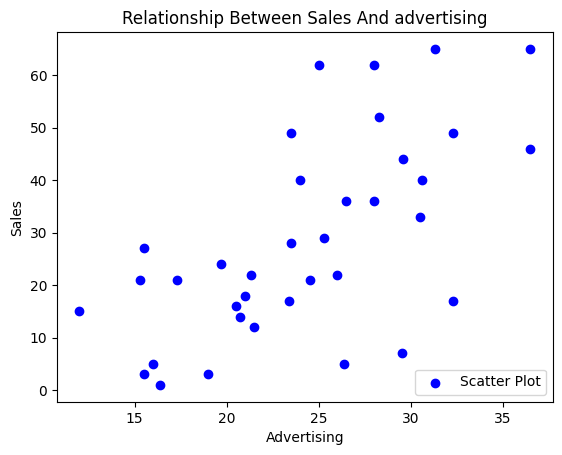

In [42]:
#plot the scatter between x and y
plt.scatter(X,y,color="blue",label="Scatter Plot")
plt.title("Relationship Between Sales And advertising")
plt.xlabel('Advertising')
plt.ylabel('Sales')
plt.legend(loc=4)
plt.show()

In [43]:
#print the dimensions of x and y
X.shape

(36,)

In [44]:
y.shape

(36,)

In [45]:
#reshaping x and y
X=X.reshape(-1,1)
y=y.reshape(-1,1)

In [46]:
#print the dimensions of x and y after reshaping
X.shape

(36, 1)

In [47]:
y.shape

(36, 1)

In [48]:
#Split X and y into training and test data sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [49]:
# print the dimensions of X_train, X_test, y_train, y_test
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(28, 1)
(8, 1)
(28, 1)
(8, 1)


In [50]:
#fit the linear model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [ ]:
#compute model slope and intercept
a=model.coef_
b=model.intercept_
print("Estimated Model Coefficient:",a)


print("Estimated intercept of Model:",b)

Estimated Model Coefficient: [[1.66205855]]
Estimated intercept of Model: [-12.45519409]


In [52]:
model.predict(X)[0:5]#predicting the value for the first 5 advertising value

array([[ 7.48950851],
       [21.61700619],
       [22.44803547],
       [13.30671344],
       [12.97430173]])

In [53]:
# to make an individual prediction using the linear regression model
print(str(model.predict(X)[[24]]))

[[14.13774271]]


In [54]:
#calculate the root mean squared error
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 12.8197563902471


In [55]:
#caluclating the r2 score
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.5875233784338036


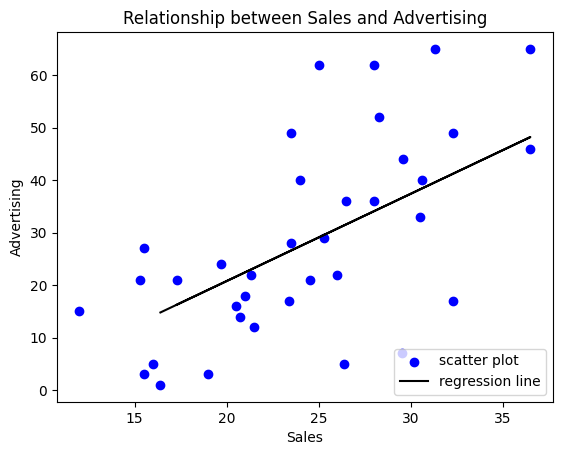

In [ ]:
#plot the regression line
plt.scatter(X,y,color="blue",label="scatter plot")
plt.plot(X_test,y_pred,color="black",label="regression line")
plt.title('Relationship between Sales and Advertising')
plt.xlabel('Sales')
plt.ylabel('Advertising')
plt.legend(loc=4)
plt.show()


In [57]:
#checking for overfitting or underfitting of the model
print("Training Set score:",model.score(X_train,y_train))
print("Testing Set score:",model.score(X_test,y_test))

Training Set score: 0.3068213698144724
Testing Set score: 0.5875233784338036
